In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

# Splitting data into different variations for feature reduction comparison;
# legend:
# df0 - no modification to time_until_disrupt
# df1 - left-hand spike in time_until_disrupt reduced
# df2 - all parameters restricted to range of validity per PSFC
df = pd.read_csv('data/cmod_clean_200ms.csv',sep=',',index_col=None)
df_regression = df.drop(columns=['disruptive','shot','Unnamed: 0']) # Drop disruptive - binary la

#df0
df0 = df_regression[df_regression.time_until_disrupt > 0]
df0 = df0.sample(frac=1.0) # Random shuffle shots
df0 = df0.replace([np.inf, -np.inf], np.nan).dropna()

#df1
df1 = df_regression[(df_regression.time_until_disrupt  > 0.02) ]
df1 = df1.sample(frac=1.0)
df1 = df1.replace([np.inf, -np.inf], np.nan).dropna()

#df2
df2 = df_regression[(df_regression.time_until_disrupt  > 0.02)
    & (df_regression.beta_n >= 0) & (df_regression.beta_n <= 2) #MHD
    & (df_regression.beta_p >= 0) & (df_regression.beta_p <= 1.5) #MHD
    & (df_regression.chisq >= 0.1) & (df_regression.chisq <= 40) #Generic
    & (df_regression.dipprog_dt >= -5e6) & (df_regression.dipprog_dt <= 5e6) #Generic
    & (df_regression.greenwald_fraction >= 0) & (df_regression.greenwald_fraction <= 1.5) #Density
    & (df_regression.kappa >= 0.8) & (df_regression.kappa <= 2) #VDE
    & (df_regression.li >= 0.2) & (df_regression.li <= 4.5) #MHD
    & (df_regression.lower_gap >= 0.025) & (df_regression.lower_gap <= 0.25) #VDE
    & (df_regression.n_e >= 0.2e20) & (df_regression.n_e <= 7e20) #Density
    & (df_regression.n_equal_1_mode >= 0) & (df_regression.n_equal_1_mode <= 0.02) #MHD
    & (df_regression.n_over_ncrit >= -3) & (df_regression.n_over_ncrit <= 3) #VDE
    & (df_regression.p_icrf >= 0) #Density, Radiation
    & (df_regression.p_lh >= 0) #Density, Radiation
    & (df_regression.p_oh >= 0) & (df_regression.p_oh <= 5.0e6) #Density, Radiation
    & (df_regression.p_rad >= 0) #Radiation
    & (df_regression.q0 >= 0) & (df_regression.q0 <= 2) #MHD
    & (df_regression.q95 >= 0) #MHD
    & (df_regression.qstar >= 0) #MHD
    & (df_regression.radiated_fraction >= 0) & (df_regression.radiated_fraction <= 15) #Radiation
    & (df_regression.ssep >= -1) & (df_regression.ssep <= 1) #Generic
    & (df_regression.upper_gap >= 0) #VDE
    & (df_regression.v_loop >= -7) & (df_regression.v_loop <= 7) #Generic, Radiation
    & (df_regression.wmhd >= 0) & (df_regression.wmhd <= 3e5) #Radiation
    & (df_regression.z_error >= -1) & (df_regression.z_error <= 1) #VDE
    & (df_regression.zcur >= -0.5) & (df_regression.zcur <= 0.5) #VDE
    ]
df2 = df2.sample(frac=1.0)
df2 = df2.replace([np.inf, -np.inf], np.nan).dropna()

array([[<Axes: title={'center': 'time'}>,
        <Axes: title={'center': 'a_minor'}>,
        <Axes: title={'center': 'beta_n'}>,
        <Axes: title={'center': 'beta_p'}>,
        <Axes: title={'center': 'bt'}>,
        <Axes: title={'center': 'chisq'}>,
        <Axes: title={'center': 'dbetap_dt'}>,
        <Axes: title={'center': 'dip_dt'}>],
       [<Axes: title={'center': 'dip_smoothed'}>,
        <Axes: title={'center': 'dipprog_dt'}>,
        <Axes: title={'center': 'dli_dt'}>,
        <Axes: title={'center': 'dn_dt'}>,
        <Axes: title={'center': 'dprad_dt'}>,
        <Axes: title={'center': 'dwmhd_dt'}>,
        <Axes: title={'center': 'greenwald_fraction'}>,
        <Axes: title={'center': 'i_efc'}>],
       [<Axes: title={'center': 'ip'}>,
        <Axes: title={'center': 'ip_error'}>,
        <Axes: title={'center': 'ip_prog'}>,
        <Axes: title={'center': 'kappa'}>,
        <Axes: title={'center': 'kappa_area'}>,
        <Axes: title={'center': 'li'}>,
        <Ax

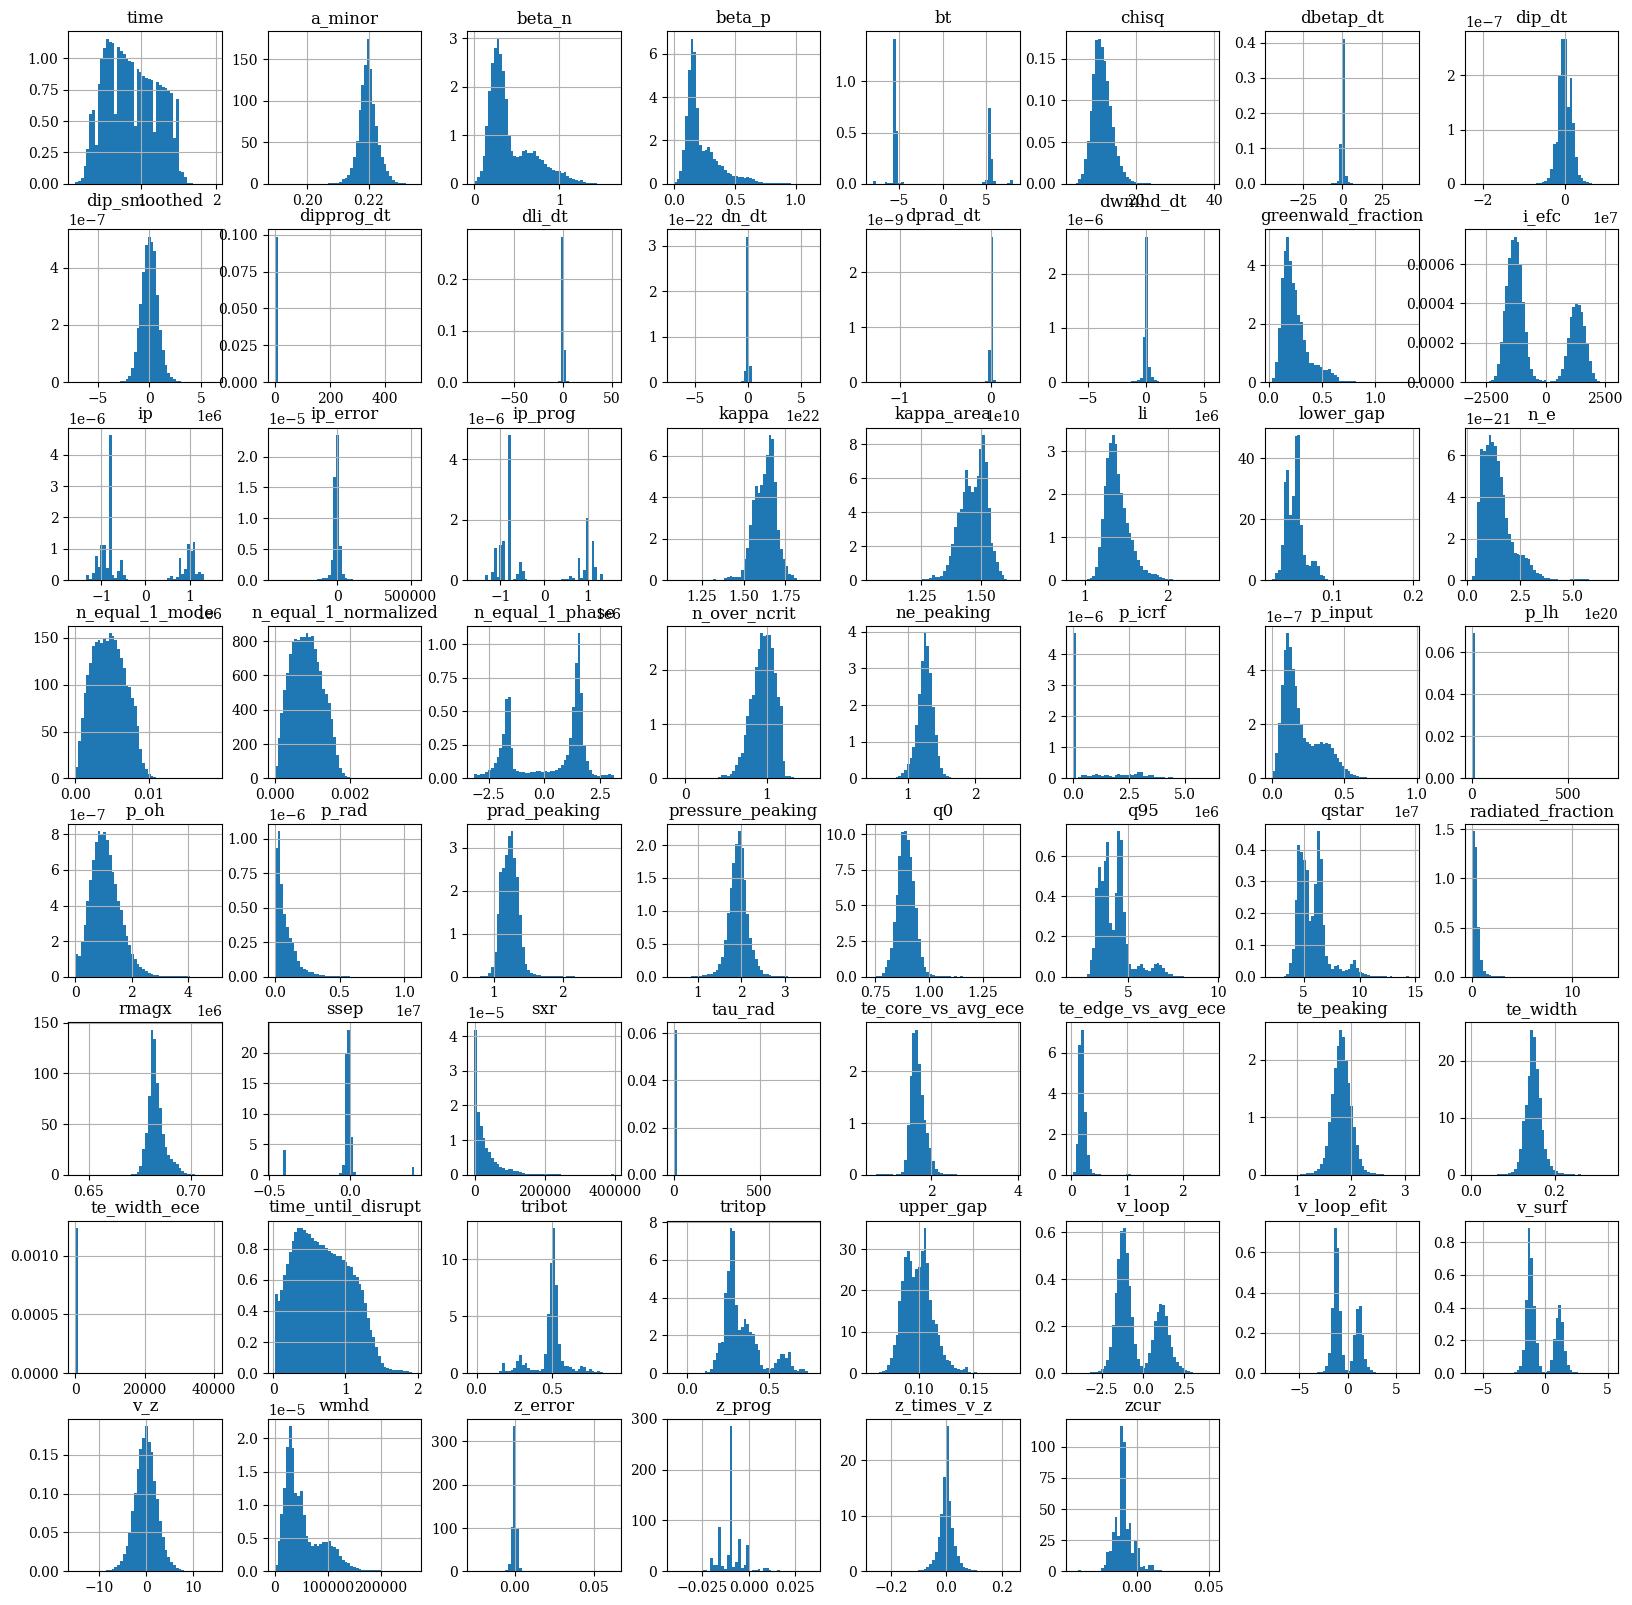

In [43]:
df2.hist(figsize=(20,20),bins=50,density=True)

In [44]:
t_max = df_regression["time_until_disrupt"].max()
t_min = df_regression["time_until_disrupt"].min()
t_dis_width = (t_max - t_min) / 50
t_dis_width

np.float64(0.06631599813699722)

In [45]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

############# Important Flag ##############
log_time = False
###########################################

def create_train_test_split(dataset,log_time=False):

    def return_x_y(dataframe,log_time=False):
        x = dataframe.drop(columns=['time_until_disrupt']).to_numpy()
        if log_time:
            y = np.log(dataframe['time_until_disrupt'].values)
        else:
            y = dataframe['time_until_disrupt'].values

        return x,y

    Nt = int(0.7 * len(dataset))
    train = dataset[:Nt]
    test_val = dataset[Nt:]

    Nv = int(0.5 *len(test_val))
    val = test_val[:Nv]
    test = test_val[Nv:]
    print("Total dataset size: ",len(dataset))
    print("Number of Training data points: ",len(train))
    print("Number of Validation data points: ",len(val))
    print("Number of Testing data points: ",len(test))

    train_x,train_y = return_x_y(train,log_time)
    val_x,val_y = return_x_y(val,log_time)
    test_x,test_y = return_x_y(test,log_time)

    return train_x,train_y,val_x,val_y,test_x,test_y

# need to split all of our datasets!
train_x0,train_y0,val_x0,val_y0,test_x0,test_y0 = create_train_test_split(df0,log_time=log_time)
train_x1,train_y1,val_x1,val_y1,test_x1,test_y1 = create_train_test_split(df1,log_time=log_time)
train_x2,train_y2,val_x2,val_y2,test_x2,test_y2 = create_train_test_split(df2,log_time=log_time)

Total dataset size:  61843
Number of Training data points:  43290
Number of Validation data points:  9276
Number of Testing data points:  9277
Total dataset size:  56206
Number of Training data points:  39344
Number of Validation data points:  8431
Number of Testing data points:  8431
Total dataset size:  54761
Number of Training data points:  38332
Number of Validation data points:  8214
Number of Testing data points:  8215


In [46]:
# remember to also do everything here for all of our various versions of the dataset

feature_scaler0 = StandardScaler() #MinMaxScaler((-1,1))
feature_scaler0.fit(df0.drop(columns=['time_until_disrupt']).to_numpy()) # Lets use global statistics for simplicity here.

feature_scaler1 = StandardScaler()
feature_scaler1.fit(df1.drop(columns=['time_until_disrupt']).to_numpy())

feature_scaler2 = StandardScaler()
feature_scaler2.fit(df2.drop(columns=['time_until_disrupt']).to_numpy())

x_train_scaled0 = feature_scaler0.transform(train_x0)
x_val_scaled0 = feature_scaler0.transform(val_x0)
x_test_scaled0 = feature_scaler0.transform(test_x0)

x_train_scaled1 = feature_scaler1.transform(train_x1)
x_val_scaled1 = feature_scaler1.transform(val_x1)
x_test_scaled1 = feature_scaler1.transform(test_x1)

x_train_scaled2 = feature_scaler2.transform(train_x2)
x_val_scaled2 = feature_scaler2.transform(val_x2)
x_test_scaled2 = feature_scaler2.transform(test_x2)

#print("Features")
#print("Training:",x_train_scaled.max(),x_train_scaled.min())
#print("Validation:",x_val_scaled.max(),x_val_scaled.min())
#print("Testing:",x_test_scaled.max(),x_test_scaled.min())

#df0

if log_time: # Declared above
    target_scaler0 = MinMaxScaler((0,1))
    target_scaler0.fit(np.log(df0['time_until_disrupt'].values.reshape(-1,1))) # Using global statistics for simplicity here

    y_train_scaled0 = target_scaler0.transform(train_y0.reshape(-1,1)).flatten()
    y_val_scaled0 = target_scaler0.transform(val_y0.reshape(-1,1)).flatten()
    y_test_scaled0 = target_scaler0.transform(test_y0.reshape(-1,1)).flatten()
else:
    y_train_scaled0 = train_y0.copy()
    y_val_scaled0 = val_y0.copy()
    y_test_scaled0 = test_y0.copy()

#df1

if log_time: # Declared above
    target_scaler1 = MinMaxScaler((0,1))
    target_scaler1.fit(np.log(df1['time_until_disrupt'].values.reshape(-1,1)))

    y_train_scaled1 = target_scaler1.transform(train_y1.reshape(-1,1)).flatten()
    y_val_scaled1 = target_scaler1.transform(val_y1.reshape(-1,1)).flatten()
    y_test_scaled1 = target_scaler1.transform(test_y1.reshape(-1,1)).flatten()
else:
    y_train_scaled1 = train_y1.copy()
    y_val_scaled1 = val_y1.copy()
    y_test_scaled1 = test_y1.copy()

#df2

if log_time: # Declared above
    target_scaler2 = MinMaxScaler((0,1))
    target_scaler2.fit(np.log(df2['time_until_disrupt'].values.reshape(-1,1)))

    y_train_scaled2 = target_scaler2.transform(train_y2.reshape(-1,1)).flatten()
    y_val_scaled2 = target_scaler2.transform(val_y2.reshape(-1,1)).flatten()
    y_test_scaled2 = target_scaler2.transform(test_y2.reshape(-1,1)).flatten()
else:
    y_train_scaled2 = train_y2.copy()
    y_val_scaled2 = val_y2.copy()
    y_test_scaled2 = test_y2.copy()

#print(" ")
#print("Targets")
#print("Training:",y_train_scaled.max(),y_train_scaled.min())
#print("Validation:",y_val_scaled.max(),y_val_scaled.min())
#print("Testing:",y_test_scaled.max(),y_test_scaled.min())

In [47]:
import torch
from torch import nn
from torch.nn import BatchNorm1d

class MLP(nn.Module):
    def __init__(self,input_shape,output_shape):
        super(MLP, self).__init__()

        self.init_layer = nn.Linear(input_shape,64)
        self.B0 = nn.BatchNorm1d(64)
        self.L1 = nn.Linear(64,256)
        self.B1 = nn.BatchNorm1d(256)
        self.L2 = nn.Linear(256,512)
        self.B2 = nn.BatchNorm1d(512)
        self.L3 = nn.Linear(512,256)
        self.B3 = nn.BatchNorm1d(256)
        self.L4 = nn.Linear(256,128)
        self.B4 = nn.BatchNorm1d(128)
        self.output = nn.Linear(128,output_shape)
        self.activation = nn.SELU()
        self.output_activation = nn.Softplus()
    def forward(self,x):

        x = self.activation(self.B0(self.init_layer(x))) # SELU(BNorm(Linear(x)))
        x = self.activation(self.B1(self.L1(x)))
        x = self.activation(self.B2(self.L2(x)))
        x = self.activation(self.B3(self.L3(x)))
        x = self.activation(self.B4(self.L4(x)))
        x = self.output_activation(self.output(x)).squeeze(1) # Time must be > 0, ReLU is good choice here.

        return x

regressor0 = MLP(input_shape=x_train_scaled0.shape[1],output_shape=1) # Singular output
regressor1 = MLP(input_shape=x_train_scaled1.shape[1],output_shape=1)
regressor2 = MLP(input_shape=x_train_scaled2.shape[1],output_shape=1)
#print(regressor)

In [48]:
regressor0(torch.tensor(x_train_scaled0[:3]).float())
regressor1(torch.tensor(x_train_scaled1[:3]).float())
regressor2(torch.tensor(x_train_scaled2[:3]).float())

tensor([0.9235, 0.1462, 1.4996], grad_fn=<SqueezeBackward1>)

In [49]:
from torch.utils.data import TensorDataset, DataLoader

#df0
train_dataset0 = TensorDataset(torch.tensor(x_train_scaled0),torch.tensor(y_train_scaled0))
val_dataset0 = TensorDataset(torch.tensor(x_val_scaled0),torch.tensor(y_val_scaled0))
test_dataset0 = TensorDataset(torch.tensor(x_test_scaled0),torch.tensor(y_test_scaled0))

#df1
train_dataset1 = TensorDataset(torch.tensor(x_train_scaled1),torch.tensor(y_train_scaled1))
val_dataset1 = TensorDataset(torch.tensor(x_val_scaled1),torch.tensor(y_val_scaled1))
test_dataset1 = TensorDataset(torch.tensor(x_test_scaled1),torch.tensor(y_test_scaled1))

#df2
train_dataset2 = TensorDataset(torch.tensor(x_train_scaled2),torch.tensor(y_train_scaled2))
val_dataset2 = TensorDataset(torch.tensor(x_val_scaled2),torch.tensor(y_val_scaled2))
test_dataset2 = TensorDataset(torch.tensor(x_test_scaled2),torch.tensor(y_test_scaled2))

In [50]:
train_dataset2.__getitem__(0)

(tensor([ 1.4503,  0.1271,  3.7007,  3.1338, -0.7272, -0.6430,  0.8026, -3.3913,
          0.3328, -0.0171, -0.4756,  0.3723, -0.3699,  0.9327,  2.5562, -0.9436,
         -0.8669,  0.5435, -0.8776, -0.7599, -1.0180, -1.3494,  0.9913,  3.0585,
          0.9364,  0.9765,  0.8693, -1.9352,  0.2757,  2.2868,  2.0387, -0.0298,
         -0.6871,  1.4097, -0.4681,  0.7379,  0.7457, -0.6147, -0.6429, -0.0505,
          3.3815,  0.1605,  1.6944, -0.0152,  1.2806,  0.0824,  0.8645, -0.2911,
         -0.0383,  0.5799, -0.1550,  0.5251, -0.1842, -0.3067, -0.2682,  0.4755,
          3.3065,  0.4976, -0.1617, -0.3877, -0.0448], dtype=torch.float64),
 tensor(0.4387, dtype=torch.float64))

In [51]:
#df0
train_loader0 = DataLoader(train_dataset0,batch_size=10)

for i,data in enumerate(train_loader0):
    x = data[0]
    y = data[1]
    print("Batch {0}".format(i),"-> x shape: ",x.shape," y shape: ",y.shape)
    break

#df1
train_loader1 = DataLoader(train_dataset1,batch_size=10)

for i,data in enumerate(train_loader1):
    x = data[0]
    y = data[1]
    print("Batch {0}".format(i),"-> x shape: ",x.shape," y shape: ",y.shape)
    break

#df2
train_loader2 = DataLoader(train_dataset2,batch_size=10)

for i,data in enumerate(train_loader2):
    x = data[0]
    y = data[1]
    print("Batch {0}".format(i),"-> x shape: ",x.shape," y shape: ",y.shape)
    break

Batch 0 -> x shape:  torch.Size([10, 61])  y shape:  torch.Size([10])
Batch 0 -> x shape:  torch.Size([10, 61])  y shape:  torch.Size([10])
Batch 0 -> x shape:  torch.Size([10, 61])  y shape:  torch.Size([10])


In [52]:
# Create dataloaders to iterate.
# We take as input the three TensorDatasets along with the batch sizes we want to use.
def CreateLoaders(train_dataset,val_dataset,test_dataset,train_batch,val_batch,test_batch):
    train_loader = DataLoader(train_dataset,
                            batch_size=train_batch,
                            shuffle=True)
    val_loader =  DataLoader(val_dataset,
                            batch_size=val_batch,
                            shuffle=False)
    test_loader =  DataLoader(test_dataset,
                            batch_size=val_batch,
                            shuffle=False)
    return train_loader,val_loader,test_loader

train_loader0,val_loader0,test_loader0 = CreateLoaders(train_dataset0,val_dataset0,test_dataset0,10,10,10)
train_loader1,val_loader1,test_loader1 = CreateLoaders(train_dataset1,val_dataset1,test_dataset1,10,10,10)
train_loader2,val_loader2,test_loader2 = CreateLoaders(train_dataset2,val_dataset2,test_dataset2,10,10,10)

In [53]:
config0 = {"seed":8,
          "name": "Fusion_Regression_Basic_Clean",
          "run_val":1,
          "model": {
               "input_shape":61,
               "output_shape": 1,
           },
          "optimizer": {
                "lr": 7e-4,
            },
          "num_epochs": 20,
          "dataloader": {
            "train": {
                "batch_size": 64
            },
            "val": {
                "batch_size": 64
            },
            "test": {
                "batch_size": 64
            },
          },
            "output": {
                "dir":"./"
            }
}

config1 = {"seed":8,
          "name": "Fusion_Regression_Filtered_Time",
          "run_val":1,
          "model": {
               "input_shape":61,
               "output_shape": 1,
           },
          "optimizer": {
                "lr": 7e-4,
            },
          "num_epochs": 20,
          "dataloader": {
            "train": {
                "batch_size": 64
            },
            "val": {
                "batch_size": 64
            },
            "test": {
                "batch_size": 64
            },
          },
            "output": {
                "dir":"./"
            }
}

config2 = {"seed":8,
          "name": "Fusion_Regression_Bounded_Vals",
          "run_val":1,
          "model": {
               "input_shape":61,
               "output_shape": 1,
           },
          "optimizer": {
                "lr": 7e-4,
            },
          "num_epochs": 20,
          "dataloader": {
            "train": {
                "batch_size": 64
            },
            "val": {
                "batch_size": 64
            },
            "test": {
                "batch_size": 64
            },
          },
            "output": {
                "dir":"./"
            }
}

In [54]:
import os
import json
import random
import pkbar
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn as nn
import datetime
import shutil
import time

def trainer(config,train_dataset,val_dataset,test_dataset):
    # Setup random seed
    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])
    random.seed(config['seed'])
    torch.cuda.manual_seed(config['seed'])

    # Create experiment name
    exp_name = config['name']
    print(exp_name)

    # Create directory structure
    output_folder = config['output']['dir']
    output_path = os.path.join(output_folder,exp_name)
    os.makedirs(output_path,exist_ok=True)

    with open(os.path.join(output_path,'config.json'),'w') as outfile:
        json.dump(config, outfile)


       # Load the dataset
    print('Creating Loaders.')
    train_batch_size = config['dataloader']['train']['batch_size']
    val_batch_size = config['dataloader']['val']['batch_size']
    test_batch_size = config['dataloader']['val']['batch_size']

    train_loader,val_loader,test_loader = CreateLoaders(train_dataset,val_dataset,test_dataset,train_batch_size,val_batch_size,test_batch_size)

    history = {'train_loss':[],'val_loss':[],'lr':[]}


    print("Training Size: {0}".format(len(train_loader.dataset)))
    print("Validation Size: {0}".format(len(val_loader.dataset)))

    # Create the model
    input_shape = config['model']['input_shape']
    output_shape = config['model']['output_shape']
    net = MLP(input_shape=input_shape,output_shape=output_shape)
    t_params = sum(p.numel() for p in net.parameters())
    print("Network Parameters: ",t_params)
    device = torch.device('cuda')
    net.to('cuda')

    # Optimizer
    num_epochs=int(config['num_epochs'])
    lr = float(config['optimizer']['lr'])

    optimizer = optim.Adam(list(filter(lambda p: p.requires_grad, net.parameters())), lr=lr)
    num_steps = len(train_loader) * num_epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max=num_steps, last_epoch=-1,
                                                           eta_min=0)

    startEpoch = 0
    global_step = 0

    print('===========  Optimizer  ==================:')
    print('      LR:', lr)
    print('      num_epochs:', num_epochs)
    print('')


    # Loss Function
    loss_function = nn.HuberLoss()
    for epoch in range(startEpoch,num_epochs):

        kbar = pkbar.Kbar(target=len(train_loader), epoch=epoch, num_epochs=num_epochs, width=20, always_stateful=False)

        net.train()
        running_loss = 0.0

        for i, data in enumerate(train_loader):
            input  = data[0].to('cuda').float()
            y = data[1].to('cuda').float()

            optimizer.zero_grad()

            with torch.set_grad_enabled(True):
                y_hat = net(input)

            loss = loss_function(y,y_hat)

            loss.backward()
            #torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=0.5,error_if_nonfinite=True)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * input.shape[0]
            kbar.update(i, values=[("loss", loss.item())])
            global_step += 1


        history['train_loss'].append(running_loss / len(train_loader.dataset))
        history['lr'].append(scheduler.get_last_lr()[0])


        ######################
        ## validation phase ##
        ######################
        if bool(config['run_val']):
            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for i, data in enumerate(val_loader):
                    input  = data[0].to('cuda').float()
                    y = data[1].to('cuda').float()
                    y_hat = net(input)
                    loss = loss_function(y,y_hat)

                    val_loss += loss

            val_loss = val_loss.cpu().numpy() / len(val_loader)

            history['val_loss'].append(val_loss)

            kbar.add(1, values=[("val_loss", val_loss.item())])

            name_output_file = config['name']+'_epoch{:02d}_val_loss_{:.6f}.pth'.format(epoch, val_loss)

        else:
            kbar.add(1,values=[('val_loss',0.)])
            name_output_file = config['name']+'_epoch{:02d}_train_loss_{:.6f}.pth'.format(epoch, running_loss / len(train_loader.dataset))

        filename = os.path.join(output_path, name_output_file)

        checkpoint={}
        checkpoint['net_state_dict'] = net.state_dict()
        checkpoint['optimizer'] = optimizer.state_dict()
        checkpoint['scheduler'] = scheduler.state_dict()
        checkpoint['epoch'] = epoch
        checkpoint['history'] = history
        checkpoint['global_step'] = global_step

        torch.save(checkpoint,filename)

        print('')

In [102]:
trainer(config2,train_dataset2,val_dataset2,test_dataset2)

Fusion_Regression_Bounded_Vals
Creating Loaders.
Training Size: 38332
Validation Size: 8214
Network Parameters:  318977
===========  Optimizer  ==================:
      LR: 0.0007
      num_epochs: 20

Epoch: 1/20
599/599 [====================] - 2s 3ms/step - loss: 0.0378 - val_loss: 0.0322

Epoch: 2/20
599/599 [====================] - 2s 3ms/step - loss: 0.0324 - val_loss: 0.0337

Epoch: 3/20
599/599 [====================] - 2s 3ms/step - loss: 0.0304 - val_loss: 0.0308

Epoch: 4/20
599/599 [====================] - 2s 3ms/step - loss: 0.0293 - val_loss: 0.0299

Epoch: 5/20
599/599 [====================] - 2s 3ms/step - loss: 0.0282 - val_loss: 0.0279

Epoch: 6/20
599/599 [====================] - 2s 3ms/step - loss: 0.0270 - val_loss: 0.0285

Epoch: 7/20
599/599 [====================] - 2s 3ms/step - loss: 0.0263 - val_loss: 0.0275

Epoch: 8/20
599/599 [====================] - 2s 3ms/step - loss: 0.0254 - val_loss: 0.0256

Epoch: 9/20
599/599 [====================] - 2s 3ms/step - lo

In [103]:
dicte0 = torch.load(os.path.join(config2['name'],os.listdir(config2['name'])[-1]))
print(dicte0.keys())

dict_keys(['net_state_dict', 'optimizer', 'scheduler', 'epoch', 'history', 'global_step'])


/tmp/ipykernel_240/499468354.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dicte0 = torch.load(os.path.join(config2['name'],os.listdir(config2['name'])[-1]))


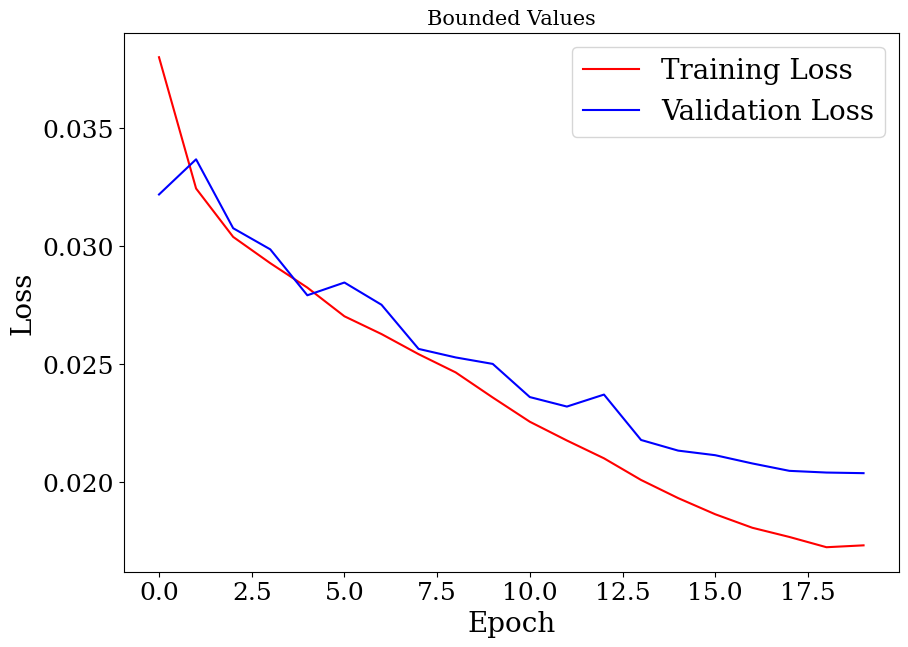

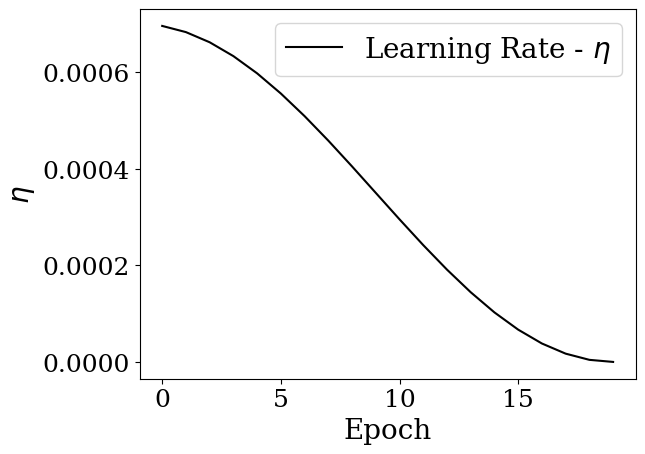

In [104]:
train_loss0 = dicte0['history']['train_loss']
val_loss0 = dicte0['history']['val_loss']
learning_rate0 = dicte0['history']['lr']

plt.figure(figsize=(10,7))
plt.plot(train_loss0,'r-',label="Training Loss")
plt.plot(val_loss0,'b-',label='Validation Loss')
plt.title('Bounded Values',fontsize=15)
plt.legend(fontsize=20)
plt.xlabel('Epoch',fontsize=20)
plt.ylabel('Loss',fontsize=20)
plt.tick_params(axis='both', labelsize=18)
plt.savefig('Bounded_Vals_Loss.pdf',format='pdf')
plt.show()

plt.plot(learning_rate0,'k-',label=r"Learning Rate - $\eta$")
plt.legend(fontsize=20)
plt.xlabel('Epoch',fontsize=20)
plt.ylabel(r'$\eta$',fontsize=20)
plt.tick_params(axis='both', labelsize=18)
plt.show()

In [105]:
input_shape0 = config2['model']['input_shape']
output_shape0 = config2['model']['output_shape']
net0 = MLP(input_shape=input_shape0,output_shape=output_shape0)
t_params = sum(p.numel() for p in net0.parameters())
print("Network Parameters: ",t_params)
device = torch.device('cuda')
net0.to('cuda')

dicte0 = torch.load(os.path.join(config2['name'],os.listdir(config2['name'])[-1]))
net0.load_state_dict(dicte0["net_state_dict"])

Network Parameters:  318977


/tmp/ipykernel_240/3787428464.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dicte0 = torch.load(os.path.join(config2['name'],os.listdir(config2['name'])[-1]))


<All keys matched successfully>

In [106]:
test_loader2 = DataLoader(test_dataset2,batch_size=config2['dataloader']['test']['batch_size'])
net0.eval() # Eval mode

predictions = []
y_true = []
kbar = pkbar.Kbar(target=len(test_loader2), width=20, always_stateful=False)
for i,data in enumerate(test_loader2):
    x = data[0].to('cuda').float()


    with torch.set_grad_enabled(False): # Same as with torch.no_grad():
        y_hat = net0(x).detach().cpu().numpy()

        if log_time: # Decalared above
            y_hat = np.exp(target_scaler2.inverse_transform(y_hat.reshape(-1,1))).flatten()
            y_true.append(np.exp(target_scaler2.inverse_transform(data[1].numpy().reshape(-1,1))).flatten())
        else:
            y_true.append(data[1].numpy())

    predictions.append(y_hat)

    kbar.update(i)

predictions = np.concatenate(predictions)
y_true = np.concatenate(y_true)

123/129 [==================>.] - ETA: 0s

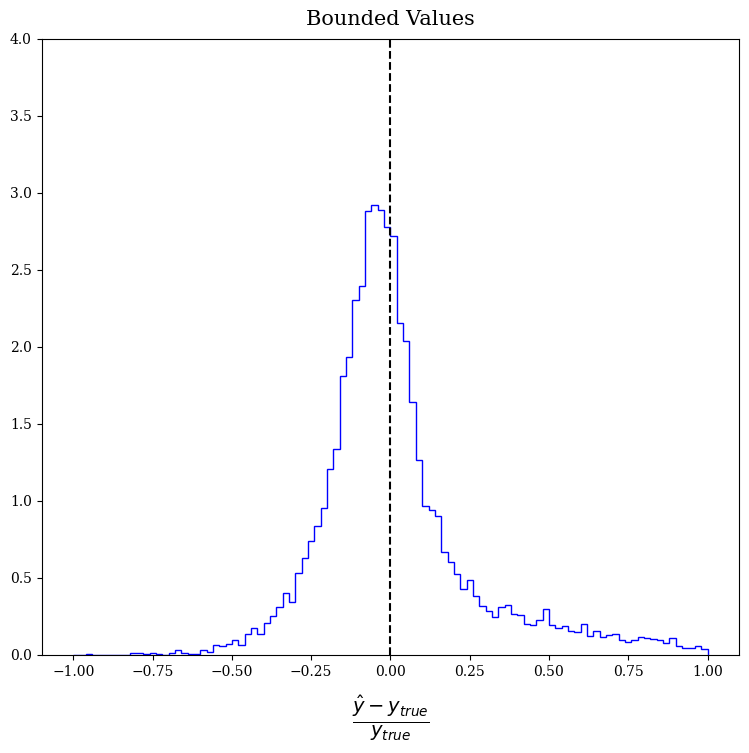

In [107]:
relative_residuals = (predictions - y_true) / (y_true + 1e-7)

plt.figure(figsize=(9,8))
plt.hist(relative_residuals,density=True,color='blue',histtype='step',label='Relative Residuals',range=[-1,1],bins=100)
plt.title('Bounded Values',fontsize=15,pad=10)
plt.xlabel(r'$\frac{\hat{y} - y_{true}}{y_{true}}$',fontsize=20,labelpad=10)
#plt.ylabel('Density',fontsize=25,labelpad=10)
plt.vlines(0,0,4,'k','--')
plt.ylim(0,4)
plt.tick_params(axis='both')#, labelsize=18)
plt.savefig('Bounded_Vals_Result.pdf',format='pdf')